In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../model')

from evidential_mlp import EvidentialMLP
from rssm import SimplifiedRSSM

# Load processed dataset
df = pd.read_parquet('../data/processed.parquet')
trajs = pd.read_parquet('../data/trajectories.parquet')

# Load checkpoints
mlp_ckpt  = torch.load('../model/checkpoint.pt',      weights_only=False)
rssm_ckpt = torch.load('../model/rssm_checkpoint.pt', weights_only=False)

print(f'Dataset: {len(df)} points, {len(trajs.traj_id.unique())} trajectories')
print(f'Regimes: {df.regime.value_counts().to_dict()}')

Dataset: 200 points, 300 trajectories
Regimes: {'continuum': 100, 'transitional': 86, 'free_molecular': 14}


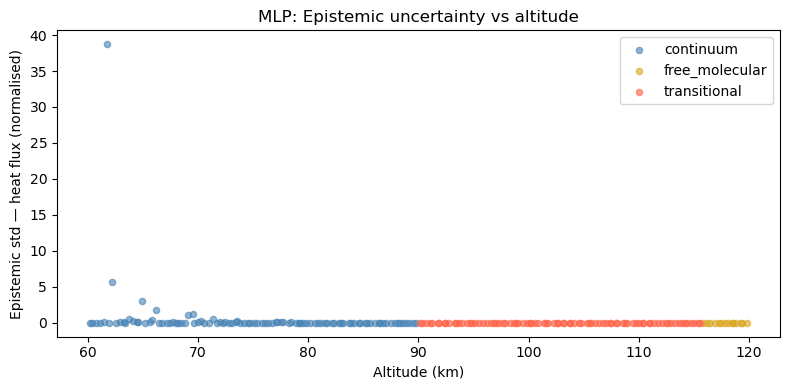

In [2]:
mlp = EvidentialMLP(in_dim=4)
mlp.load_state_dict(mlp_ckpt['model'])
mlp.eval()

X_mean = mlp_ckpt['X_mean']
X_std  = mlp_ckpt['X_std']

X_raw = df[['altitude_km','velocity_ms','alpha_deg','Twall_K']].values.astype(np.float32)
X = torch.tensor((X_raw - X_mean) / X_std)

with torch.no_grad():
    mu, v, alpha, beta = mlp(X)
    ep_var = beta / (v * (alpha - 1).clamp(min=1e-4))
    ep_std = ep_var.sqrt().numpy()

df['ep_std_q_mlp'] = ep_std[:, 2]   # q is index 2

fig, ax = plt.subplots(figsize=(8, 4))
colors = {'continuum': 'steelblue', 'transitional': 'tomato', 'free_molecular': 'goldenrod'}
for regime, grp in df.groupby('regime'):
    ax.scatter(grp['altitude_km'], grp['ep_std_q_mlp'],
               label=regime, color=colors[regime], alpha=0.6, s=20)
ax.set_xlabel('Altitude (km)')
ax.set_ylabel('Epistemic std — heat flux (normalised)')
ax.set_title('MLP: Epistemic uncertainty vs altitude')
ax.legend()
plt.tight_layout()
plt.savefig('../data/mlp_uncertainty_vs_altitude.png', dpi=150)
plt.show()

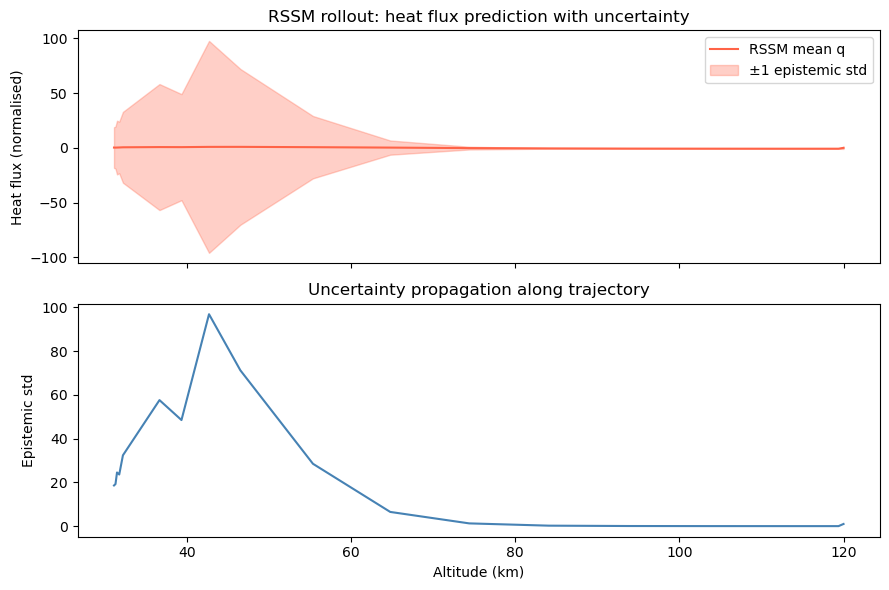

In [3]:
rssm = SimplifiedRSSM(obs_dim=4, hidden_dim=64, latent_dim=32, out_dim=3)
rssm.load_state_dict(rssm_ckpt['model'])
rssm.eval()

X_mean_r = rssm_ckpt['X_mean']
X_std_r  = rssm_ckpt['X_std']

# Pick a representative trajectory
traj = trajs[trajs['traj_id'] == 0].sort_values('time_s')
X_traj = traj[['altitude_km','velocity_ms','alpha_deg','Twall_K']].values.astype(np.float32)
X_traj_norm = torch.tensor((X_traj - X_mean_r) / X_std_r)

means, ep_stds = rssm.rollout(X_traj_norm)
means   = means.numpy()
ep_stds = ep_stds.numpy()

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Heat flux prediction with uncertainty band
ax = axes[0]
ax.plot(traj['altitude_km'].values, means[:, 2], color='tomato', label='RSSM mean q')
ax.fill_between(traj['altitude_km'].values,
                means[:, 2] - ep_stds[:, 2],
                means[:, 2] + ep_stds[:, 2],
                alpha=0.3, color='tomato', label='±1 epistemic std')
ax.set_ylabel('Heat flux (normalised)')
ax.legend()
ax.set_title('RSSM rollout: heat flux prediction with uncertainty')

# Epistemic std along trajectory
ax = axes[1]
ax.plot(traj['altitude_km'].values, ep_stds[:, 2], color='steelblue')
ax.set_xlabel('Altitude (km)')
ax.set_ylabel('Epistemic std')
ax.set_title('Uncertainty propagation along trajectory')

plt.tight_layout()
plt.savefig('../data/rssm_rollout_uncertainty.png', dpi=150)
plt.show()

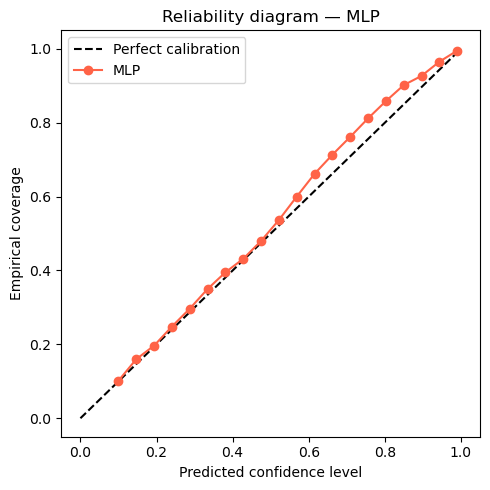

In [5]:
from sklearn.isotonic import IsotonicRegression

# Use val split for calibration — recompute on processed.parquet points
Y_raw = df[['CL_mean','CD_mean','q_mean']].values.astype(np.float32)
Y_mean_m = mlp_ckpt['Y_mean']
Y_std_m  = mlp_ckpt['Y_std']
Y = torch.tensor((Y_raw - Y_mean_m) / Y_std_m)

confidence_levels = np.linspace(0.1, 0.99, 20)
empirical_coverage = []

with torch.no_grad():
    mu, v, alpha, beta = mlp(X)

for cl in confidence_levels:
    # NIG predictive interval via Student-t
    from scipy.stats import t as student_t
    df_nig = (2 * alpha.numpy())
    scale  = (beta.numpy() * (1 + 1/v.numpy()) / alpha.numpy()) ** 0.5
    lo = mu.numpy() - student_t.ppf((1+cl)/2, df_nig) * scale
    hi = mu.numpy() + student_t.ppf((1+cl)/2, df_nig) * scale
    y_np = Y.numpy()
    covered = ((y_np >= lo) & (y_np <= hi)).mean()
    empirical_coverage.append(covered)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
ax.plot(confidence_levels, empirical_coverage, 'o-', color='tomato', label='MLP')
ax.set_xlabel('Predicted confidence level')
ax.set_ylabel('Empirical coverage')
ax.set_title('Reliability diagram — MLP')
ax.legend()
plt.tight_layout()
plt.savefig('../data/calibration_mlp.png', dpi=150)
plt.show()

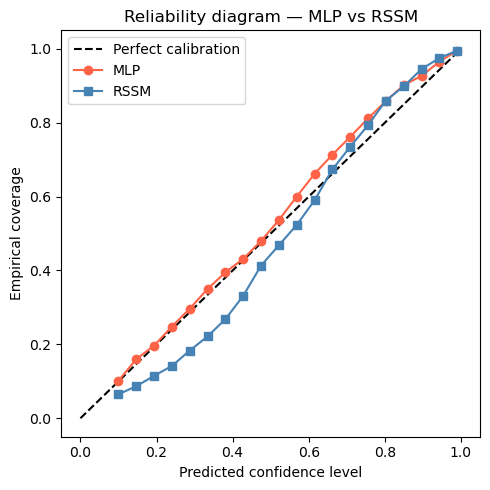

In [7]:
# Cell 5 — RSSM calibration reliability diagram
FEATURE_COLS = ['altitude_km', 'velocity_ms', 'alpha_deg', 'Twall_K']
TARGET_COLS = ['CL_mean', 'CD_mean', 'q_mean']
Y_raw = df[TARGET_COLS].values.astype(np.float32)
Y_mean_r = Y_raw.mean(0)
Y_std_r  = Y_raw.std(0)
Y_norm = torch.tensor((Y_raw - Y_mean_r) / Y_std_r)

# Build RSSM predictions on the processed dataset
# Treat each point as a length-1 sequence
X_mean_r = rssm_ckpt['X_mean']
X_std_r  = rssm_ckpt['X_std']
Y_mean_r = rssm_ckpt['Y_mean']
Y_std_r  = rssm_ckpt['Y_std']

X_raw = df[FEATURE_COLS].values.astype(np.float32)
Y_raw = df[TARGET_COLS].values.astype(np.float32)

X_norm = torch.tensor((X_raw - X_mean_r) / X_std_r)
Y_norm = torch.tensor((Y_raw - Y_mean_r) / Y_std_r)

all_mu, all_v, all_alpha, all_beta = [], [], [], []
rssm.eval()
with torch.no_grad():
    for i in range(len(X_norm)):
        x_seq = X_norm[i].unsqueeze(0).unsqueeze(0)  # (1, 1, 4)
        mu, v, alpha, beta, _ = rssm(x_seq)
        all_mu.append(mu.squeeze())
        all_v.append(v.squeeze())
        all_alpha.append(alpha.squeeze())
        all_beta.append(beta.squeeze())

mu_r    = torch.stack(all_mu).numpy()
v_r     = torch.stack(all_v).numpy()
alpha_r = torch.stack(all_alpha).numpy()
beta_r  = torch.stack(all_beta).numpy()
y_np    = Y_norm.numpy()

from scipy.stats import t as student_t

confidence_levels = np.linspace(0.1, 0.99, 20)
rssm_coverage = []

for cl in confidence_levels:
    df_nig = 2 * alpha_r
    scale  = (beta_r * (1 + 1/v_r) / alpha_r) ** 0.5
    lo = mu_r - student_t.ppf((1+cl)/2, df_nig) * scale
    hi = mu_r + student_t.ppf((1+cl)/2, df_nig) * scale
    covered = ((y_np >= lo) & (y_np <= hi)).mean()
    rssm_coverage.append(covered)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
ax.plot(confidence_levels, empirical_coverage, 'o-', color='tomato',    label='MLP')
ax.plot(confidence_levels, rssm_coverage,      's-', color='steelblue', label='RSSM')
ax.set_xlabel('Predicted confidence level')
ax.set_ylabel('Empirical coverage')
ax.set_title('Reliability diagram — MLP vs RSSM')
ax.legend()
plt.tight_layout()
plt.savefig('../data/calibration_comparison.png', dpi=150)
plt.show()